# Medication EDA

`upd23b_clinical_state_on_medication` says if the patient was On or Off medication
(e.g. levodopa) during the UPDRS exam. Medication lowers motor symptoms, so it can
change the scores without the disease actually changing.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path("../data/raw")

clinical = pd.read_csv(DATA_DIR / "train_clinical_data.csv")
supplemental = pd.read_csv(DATA_DIR / "supplemental_clinical_data.csv")

MED = "upd23b_clinical_state_on_medication"
clinical["med_state"] = clinical[MED].fillna("Missing")

## How often is it recorded?

In [2]:
for name, df in [("Clinical", clinical), ("Supplemental", supplemental)]:
    print(name)
    print(df[MED].fillna("Missing").value_counts(normalize=True).mul(100).round(1))
    print()

Clinical
upd23b_clinical_state_on_medication
Missing    50.7
On         29.6
Off        19.6
Name: proportion, dtype: float64

Supplemental
upd23b_clinical_state_on_medication
Missing    49.5
On         49.2
Off         1.3
Name: proportion, dtype: float64



About half of the visits are missing it. Supplemental has almost no Off visits.

## Missing by visit month

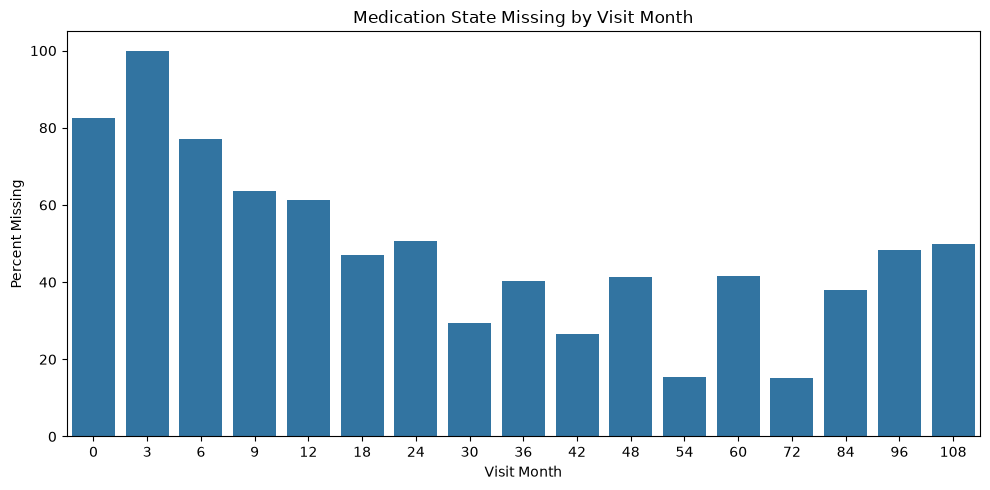

In [3]:
missing_by_month = clinical.groupby("visit_month")[MED].apply(lambda x: x.isna().mean() * 100)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_by_month.index, y=missing_by_month.values)
plt.xlabel("Visit Month")
plt.ylabel("Percent Missing")
plt.title("Medication State Missing by Visit Month")
plt.tight_layout()
plt.show()

Missing mostly at the first visits (probably patients not treated yet).

## Patients

In [4]:
patterns = clinical.groupby("patient_id")[MED].agg(
    lambda x: " + ".join(sorted(x.dropna().unique())) or "Never recorded"
)
patterns.value_counts()

upd23b_clinical_state_on_medication
Off + On          114
Never recorded     93
On                 35
Off                 6
Name: count, dtype: int64

## UPDRS by medication state

In [5]:
clinical.groupby("med_state")[["updrs_1", "updrs_2", "updrs_3", "updrs_4"]].mean().round(2)

,updrs_1,updrs_2,updrs_3,updrs_4
med_state,,,,
Missing,4.94,3.82,12.04,0.22
Off,8.76,10.04,30.87,1.99
On,9.73,9.56,24.37,2.45


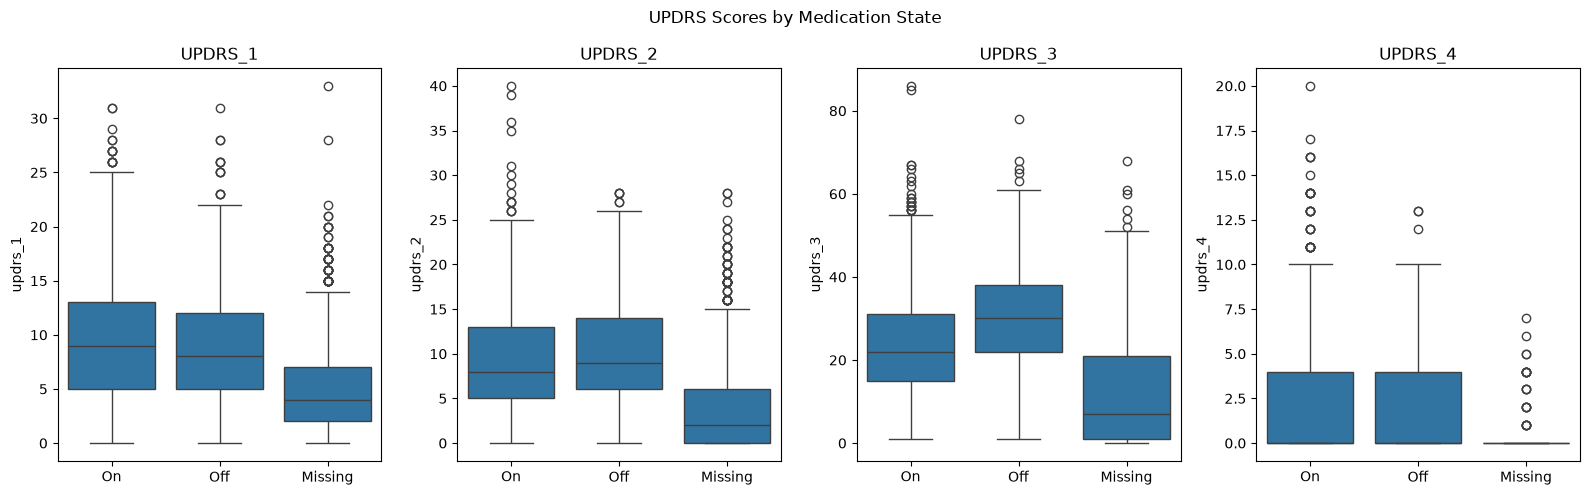

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, ["updrs_1", "updrs_2", "updrs_3", "updrs_4"]):
    sns.boxplot(data=clinical, x="med_state", y=col, order=["On", "Off", "Missing"], ax=ax)
    ax.set_xlabel("")
    ax.set_title(col.upper())

plt.suptitle("UPDRS Scores by Medication State")
plt.tight_layout()
plt.show()

Off visits have higher UPDRS 3 (motor) than On visits. Missing visits have the lowest
scores, which fits with them being early, untreated patients.

## UPDRS 3 over time

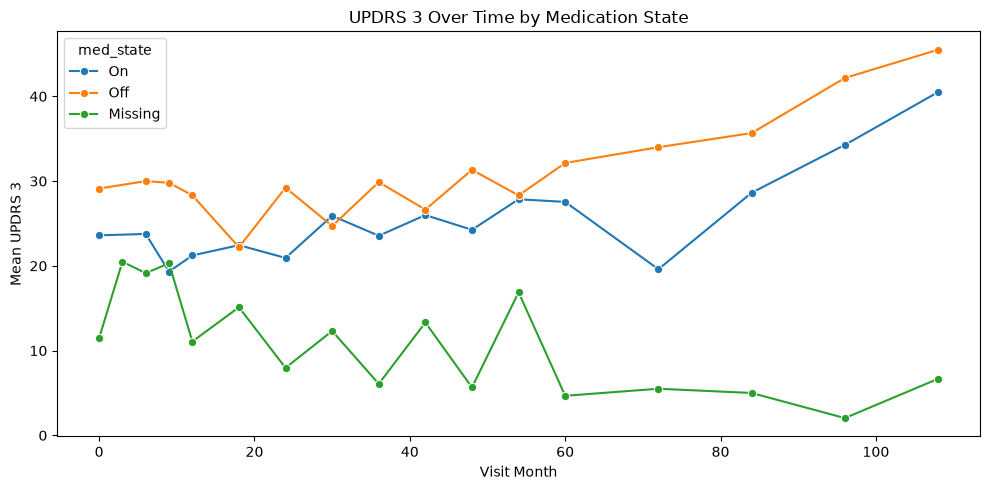

In [7]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=clinical, x="visit_month", y="updrs_3", hue="med_state",
             hue_order=["On", "Off", "Missing"], errorbar=None, marker="o")
plt.xlabel("Visit Month")
plt.ylabel("Mean UPDRS 3")
plt.title("UPDRS 3 Over Time by Medication State")
plt.tight_layout()
plt.show()